# Treat PbP data
This is the GFAS PbP treatment routine. It will produce (and save if turned on) binned and aggregated datasets in a 1Hz time resolution. Note that every single day has to be read in separately and it might take some mintues.

It uses the following datasets: 
- raw PbP observational data
- raw 1Hz data for sample flow
- scale factors in PbP_processing/detector_scaling_factors

Input needed:
    - date to be processed in the format YYYYMMDD
    - path of the data
    - path for if data and/or plots should be saved
Sub-routines needed:
- PbP_processing/GFAS101_processing
- GFAS_reading/GFAS101_read_in
- PbP_processing/loss_Calc_functions_GFAS101

Correction/Treatment applied
- attenuation
- scaling towards theoretical values
- sizing
- losses
- binning of 
    - polarization data, 
    - size distribution data, 
    - number concentration, 
    - effective diameter, 
    - and liquid water content

Output
- polarization dataframe 1 hz
- F/B dataframe 1 Hz
- N, Deff, LWC, dN/dlogDp 1Hz dataframe 
- N, Deff, LWC, dN/dlogDp 1Hz dataframe loss-corrected 



author: Lea Haberstock, Stockholm University, Department of Environmental Science, Atmospheric Unit \
developed toether with: Darrel Baumgardner and Paul Zieger

contact: lea.haberstock@aces.su.se \
used in publication: Haberstock et al. 2026 (submitted to AMT) 

In [ ]:
import sys  
import numpy as np
import pandas as pd
#import glob2
import glob, os
import os
from io import BytesIO
import datetime as dt
import calendar
from pandas.errors import EmptyDataError
from scipy.ndimage import shift
import scipy

from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as colors
import PyMieScatt as ps
import matplotlib.ticker as ticker
import matplotlib 
from zipfile import ZipFile
import dask
import dask.dataframe as dd
import importlib

from pathlib import Path

project_dir = Path.cwd().parent
sys.path.append(str(project_dir))
from GFAS101_processing import *
from GFAS_reading.GFAS101_read_in import *

import loss_Calc_functions_GFAS101 as lc
importlib.reload(lc)

<module 'loss_Calc_functions_GFAS101' from '/home/leha7253/instrumentation-GFAS/PbP_processing/loss_Calc_functions_GFAS101.py'>

In [4]:
# GFAS scaling factors for comparability with theory
scale_factors = pd.read_csv('detector_scaling_factors', index_col = 0).T


## read in and correct/size pbp data

In [ ]:
day = '20240811'
path = ''
save_data = True
save_plots = True
save_data_path = ''
save_plots_path = ''

In [6]:
pbp = readPbP101(path, day, day, '%Y%m%d', filetype='GFAS_PbP_Data', compute = False)
pbp = pbp.map_partitions(attenuation)


Scheduled 436 CSV and 0 ZIP files.


In [7]:
#calcluate ratio between sizer peak and qualifier peak and remove 
pbp['ratio'] = pbp['Sizer Peak'] / pbp['Qual Peak']
pbp = pbp[pbp['ratio'] >= 0.6]

In [9]:
pbp['scaled Sizer Peak'] = pbp['Sizer Peak'] * scale_factors['forward'].values
pbp['scaled Sizer S'] = pbp['S Peak'] * scale_factors['S'].values
pbp['scaled Sizer P'] = pbp['P Peak'] * scale_factors['P'].values
pbp['scaled r_pol'] = (pbp['scaled Sizer S'] - pbp['scaled Sizer P']) / (pbp['scaled Sizer S'] + pbp['scaled Sizer P'])
pbp['scaled F/B'] = pbp['scaled Sizer Peak']/(pbp['scaled Sizer S'] + pbp['scaled Sizer P'])
bins = np.logspace(np.log10(1e-8), np.log10(5.357364e-06), 31)
pbp['binned Sizer Peak'] = pbp['scaled Sizer Peak'].map_partitions(pd.cut, bins=bins, labels=bins[1:], include_lowest=True, meta=pd.Series(dtype="category"))


In [ ]:
meta = sizing_model(pbp._meta.copy())
pbp = pbp.map_partitions(sizing_model, meta=meta)
diameter_bins = np.array([0.85,3,4.9,6.2,7,8.5,9.5,12,14,16,18,21,22.5,24.6,26.5,28,31,33.5,36,37.5,40,42,44,48,50])# np.arange(0, 50, 1)
pbp['binned Diameter'] = pbp['Diameter'].map_partitions(pd.cut, bins=diameter_bins, labels=diameter_bins[1:],  meta=pd.Series(dtype="category"))

## create polarzation and f/b ration dfs

#### Degree of linear polarization

In [11]:
# meta for sp needs to be binned diameters and datetime
meta_sp = pd.DataFrame(columns=diameter_bins[1:], index=pbp['datetime'].unique())

In [ ]:
# meta for sp needs to be binned diameters and datetime
# meta_sp = pd.DataFrame(columns=diameter_bins[1:], index=pbp['datetime'].unique())
SP = pbp.map_partitions(lambda df: df.loc[:, ['datetime', 'binned Diameter', 'scaled r_pol']]
                        .groupby(['datetime', 'binned Diameter'], observed=False).
                        median().
                        reset_index().
                        pivot(index='datetime', columns='binned Diameter', values='scaled r_pol'), meta = meta_sp)

# save polarization data
SP = SP.compute()
if save_data == True:
    SP.to_csv(f'{save_data_path}polarization_{day}.csv')

Text(0, 0.5, 'Diameter (µm)')

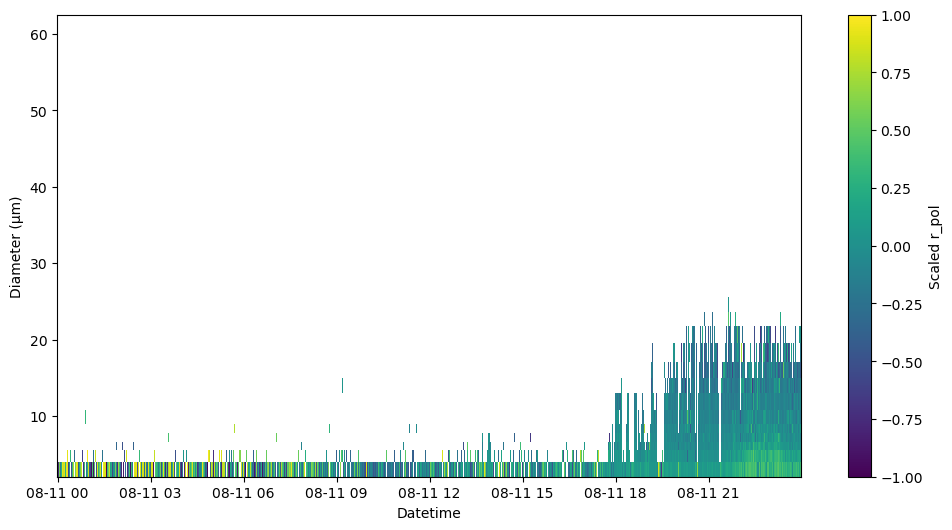

In [ ]:
x = SP.index
y = SP.columns.astype(float)
z = SP.values

x, y = np.meshgrid(x, y)
plt.figure(figsize=(12, 6))
plt.pcolormesh(x, y, z.T, shading='auto', cmap='viridis')
plt.colorbar(label='r_pol')
plt.xlabel('Datetime')
plt.ylabel('Diameter (µm)')


#### Forward-to-backward scattering ratio

In [ ]:
# meta for sp needs to be binned diameters and datetime

FB = pbp.map_partitions(lambda df: df.loc[:, ['datetime', 'binned Diameter', 'scaled F/B']]
                        .groupby(['datetime', 'binned Diameter'], observed=False).
                        median().
                        reset_index().
                        pivot(index='datetime', columns='binned Diameter', values='scaled F/B'), meta = meta_sp)

# save polarization data
FB = FB.compute()
if save_data == True:
    FB.to_csv(f'{save_data_path}FB_{day}.csv')

Text(0, 0.5, 'Diameter (µm)')

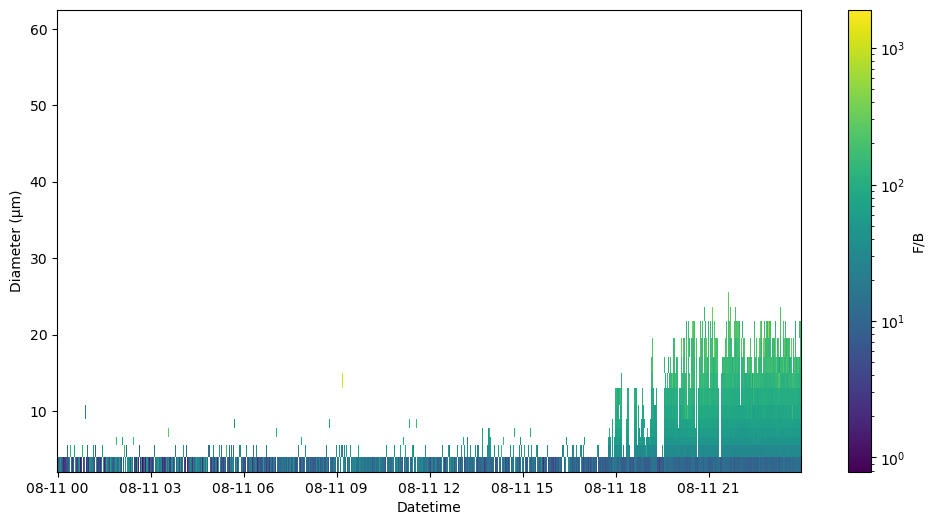

In [14]:
x = FB.index
y = FB.columns.astype(float)
z = FB.values
# find max value in z that is not inf or nan
z_max = np.nanmax(z[np.isfinite(z)])
x, y = np.meshgrid(x, y)
plt.figure(figsize=(12, 6))
plt.pcolormesh(x, y, z.T, shading='auto', cmap='viridis', norm=colors.LogNorm(vmin=np.nanmin(z[z>0]), vmax=z_max))
plt.colorbar(label='F/B')
plt.xlabel('Datetime')
plt.ylabel('Diameter (µm)')

In [15]:
del FB, SP

## make 1 Hz data

In [ ]:
starttime = (pd.to_datetime(day) - pd.Timedelta(days=1)).strftime('%Y%m%d')

hz1 =  readGFAS101(path = path, starttime = starttime, endtime = day, timefmt = '%Y%m%d', filetype='GFAS_User_Data')

'''
# if you want dn/dlogDp, then use this here: 

dlogDp = np.log10(diameter_bins[1:]) - np.log10(diameter_bins[:-1])
dlogDp[0] = np.log10(diameter_bins[1]) - np.log10(0.4499999880791)
dlogDp = pd.Series(dlogDp, index=diameter_bins[1:], dtype=float)

'''

dDp = ((diameter_bins[1:])-diameter_bins[:-1]).astype(float)
dDp[0]= diameter_bins[1]-0.7
dDp = pd.Series(dDp, index=diameter_bins[1:], dtype=float)

#### calculate real measurement time 

In [17]:
# the timestamp for each detector runs on a "clock" that increases and one "tick" is a 70 ns time stamp. 
# to calculate the amount of time that has passed between the particles is therefore the difference between the timesteps multiplied by 70 ns (70*10**-9 s)
# we want to calculate the sum of all timesteps in each "computer time second" to calculate how long the GFAS sampled in each second to then calculate the true number concentration

In [18]:
times = pbp[['datetime', 'Sizer Timestamp']]
times['Sizer diff'] = times['Sizer Timestamp'].diff(periods = 1, axis = 0)
times['Sizer diff'] = times['Sizer diff']* 70*10**-9

times['Sizer diff'] = times['Sizer diff'].where(times['Sizer diff'] > 0, 0)
measurement_duration = times.groupby('datetime').sum()['Sizer diff']
measurement_duration = measurement_duration.compute()
measurement_duration =  measurement_duration.resample('1s').mean()

In [19]:
measurement_duration =  measurement_duration.resample('1s').mean()

#### continue with size distribution

In [20]:
# if meta_sp is not defined, define it as a dataframe with columns as diameter bins and index as datetime
if 'meta_sp' not in locals():
    meta_sp = pd.DataFrame(columns=diameter_bins[1:], index=pbp['datetime'].unique())

In [ ]:
SD = pbp.map_partitions(lambda df: df.loc[:, ['datetime', 'binned Diameter', 'Diameter']]
                        .groupby(['datetime', 'binned Diameter'], observed=False)
                        .count()
                        .reset_index()
                        .pivot(index='datetime', columns='binned Diameter', values='Diameter'), meta = meta_sp
                        )
SD = SD.compute()
SD = SD.resample('1s').mean()
hz1 = hz1.resample('1s').mean()
idx = SD.index.intersection(hz1.index)

SD = SD.loc[idx].divide(hz1.loc[idx, 'Sample Volume Flow Rate (cm^3/s)'], axis = 0)
#SD.divide(measurement_duration, axis = 0)

SD.columns = SD.columns.astype(float)
dDp.index = dDp.index.astype(float) #dlogDp.index = dlogDp.index.astype(float)
SD = SD.divide(dDp, axis=1)

SD.replace(0, np.nan, inplace=True)
SD = SD.divide(measurement_duration, axis = 0)

if save_data == True:
    SD.to_csv(f'{save_data_path}SD_{day}.csv')
    

## Calculate N, LWC and Deff

In [22]:
hz1 = hz1.resample('1s').mean()
measurement_duration = measurement_duration.resample('1s').mean()

### $LWC$

In [23]:
pbp['droplet volume'] = (4/3)*np.pi*(pbp['Diameter']/2)**3
lwc = pbp.groupby('datetime')['droplet volume'].sum()


In [24]:
lwc = lwc.compute()
lwc = lwc.resample('1s').mean()
lwc = lwc.sort_index()

idx = lwc.index.intersection(hz1.index)

lwc = lwc.loc[idx].divide(hz1.loc[idx, 'Sample Volume Flow Rate (cm^3/s)'], axis = 0)
lwc = lwc.divide(measurement_duration, axis = 0)
lwc = lwc*10**-6

### $N$

In [25]:
N = pbp.groupby('datetime')['Diameter'].count()

N = N.compute()
N = N.sort_index()
N = N.resample('1s').mean()

idx = N.index.intersection(hz1.index)

N = N.divide(hz1.loc[idx, 'Sample Volume Flow Rate (cm^3/s)'], axis = 0)#.loc[idx]
N = N.divide(measurement_duration, axis = 0)


### $D_{eff}$

In [26]:
pbp['D3'] = pbp['Diameter']**3
pbp['D2'] = pbp['Diameter']**2
d = pbp[['D3', 'D2']].groupby(pbp['datetime']).sum()
D_eff = d['D3'] / d['D2']
D_eff = D_eff.compute()
D_eff = D_eff.resample('1s').mean().loc[idx]
D_eff = D_eff.sort_index()

### bring everything together into one dataframe

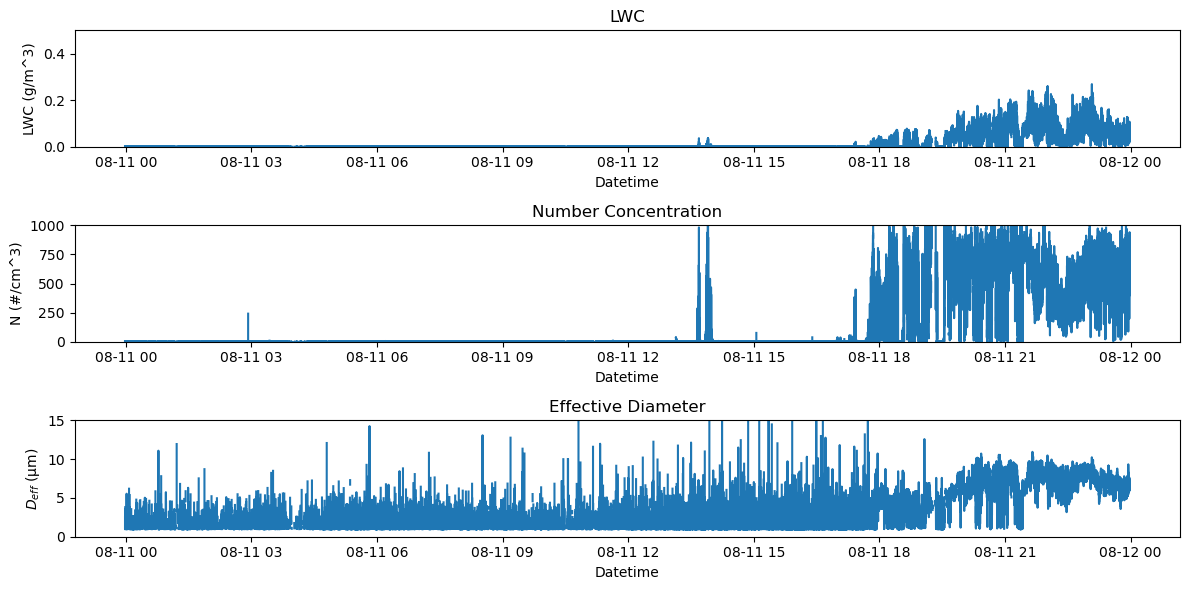

In [27]:
fig, ax = plt.subplots(3, figsize=(12, 6))
ax[0].plot(lwc.index, lwc.values)
ax[0].set(title='LWC', xlabel='Datetime', ylabel='LWC (g/m^3)', ylim = (0,0.5))
ax[1].plot(N.index, N.values)
ax[1].set(title='Number Concentration', xlabel='Datetime', ylabel='N (#/cm^3)', ylim = (0,1000))
ax[2].plot(D_eff.index, D_eff.values)
ax[2].set(title='Effective Diameter', xlabel='Datetime', ylabel='$D_{eff}$ (µm)', ylim = (0,15))
plt.tight_layout()
plt.show()

In [ ]:
parameters = pd.concat([N, lwc, D_eff], axis=1, keys=['N', 'LWC', 'D_eff'])
if save_data == True:
    parameters.to_csv(f'{save_data_path}parameters_{day}.csv')

## Loss corrections

In [ ]:
SD = pd.read_csv(f'{save_data_path}SD_{day}.csv', index_col=0, parse_dates=True)
SD.columns = SD.columns.astype(float)

starttime = (pd.to_datetime(day) - pd.Timedelta(days=1)).strftime('%Y%m%d')
hz1 = readGFAS101(path = path, starttime = starttime, endtime = day, timefmt = '%Y%m%d', filetype='GFAS_User_Data')

parameters = pd.read_csv(f'{save_data_path}parameters_{day}.csv', index_col=0, parse_dates=True)
parameters

,N,LWC,D_eff
datetime,,,
2024-08-10 23:58:52,1.184346,8.865452e-07,1.140049
2024-08-10 23:58:53,0.381186,3.118763e-06,2.500051
2024-08-10 23:58:54,NaN,NaN,NaN
2024-08-10 23:58:55,NaN,NaN,NaN
2024-08-10 23:58:56,NaN,NaN,NaN
...,...,...,...
2024-08-11 23:58:46,562.518369,3.732017e-02,6.225445
2024-08-11 23:58:47,NaN,NaN,6.505441
2024-08-11 23:58:48,754.989507,6.596233e-02,6.687266


In [30]:
hz1 = hz1.resample('1s').mean()
idx = SD.index.intersection(hz1.index)
SD = SD.loc[idx]
hz1 = hz1.loc[idx]

gfas = pd.concat([SD, hz1[['Sample Velocity (m/s)',
                           'GFAS Heading (deg)',
                           'Wind Speed (m/s)',
                           'Wind Direction (deg)',
                           ]]], axis=1)


In [31]:
def is_number(x):
    try:
        float(x)
        return True
    except:
        return False

numeric_name_cols = [c for c in gfas.columns if is_number(c)]

gfas.index.name = 'DateTime'
    # calculate overall efficiency for GFAS101
efficiency = lc.loss_calc_GFAS101(gfas, Wind = gfas, wind_GFAS=True,min_efficiency=0.01, return_sep=False)
    # create corrected GFAS101 data
corrected = gfas.resample('1min').mean()
x = lc.correction(gfas.loc[:,numeric_name_cols], efficiency, min_efficiency = 0.1, pandas = True)
x.columns = corrected.loc[:,numeric_name_cols].columns
corrected.loc[:,numeric_name_cols] = x.loc[:,numeric_name_cols]

    # calcualte N, Deff, LWC for corrected data; output = corrected parameters and corrected data for all bin sizes
correct_parameters = lc.correct_parameter(corrected.loc[:,numeric_name_cols] , min_val_series = parameters['N'], min_valED = 5)

    # create matrix for availability of efficiencies for each bin size (n_asp = aspiration efficiency, n_trm = transmission efficiency, n_tsp = transport efficiency)
        # calculate efficiencies by themselves
n_asp, n_trm, n_tsp = lc.loss_calc_GFAS101(gfas, wind_GFAS=True, Wind = gfas, return_sep=True)
        # availability of efficiencies
eff_flags = lc.efficiency_flags(n_asp, n_trm, n_tsp)

    # data array for quality assurance (0 = quality assured, 3 = not quality assured)
quality_assurance = lc.classify_quality(eff_flags)

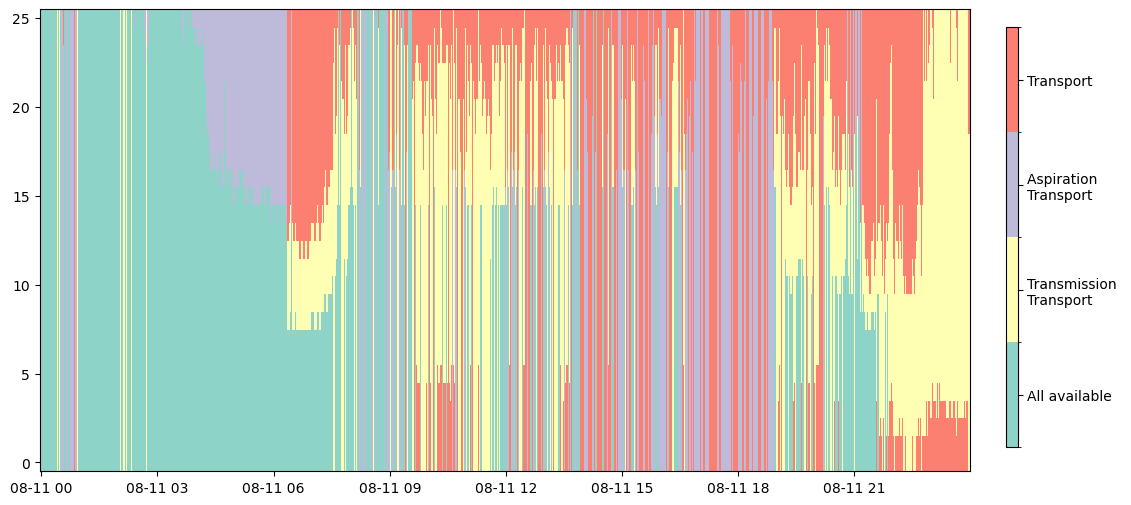

In [ ]:
import matplotlib.colors as colors
# add flags for loss calculations
fl = eff_flags#.loc[start:end]
p = fl.DateTime.values
y = np.arange(0,fl.shape[1])
P,Y = np.meshgrid(p,y)
E = fl.astype(float).values.T
norm = colors.BoundaryNorm(boundaries= np.linspace(-0.5, int(fl.max()) + 0.5, int(fl.max()) + 2), ncolors= int(fl.max())+1)
fig, ax = plt.subplots(figsize=(12, 6))
d = ax.pcolor(P,Y,E, cmap='Set3', norm = norm) #vmin=10**(-2),vmax=10**3

dax = fig.add_axes([0.93,0.15,0.01,0.7]) # [(position:) left, bottom, (size:) width, height]
dbar = fig.colorbar(d, orientation='vertical', cax = dax )
lc.plot_flag_parameters(fl, dbar)


In [33]:
quality_assurance = quality_assurance.to_pandas()
eff_flags = eff_flags.to_pandas()

In [34]:
correct_parameters.to_csv(f'/share/Lea/GFAS_sizeDistribution_data/loss_corrected/data{day}.csv')
pd.DataFrame(eff_flags).to_csv(f'/share/Lea/GFAS_sizeDistribution_data/loss_corrected/efficiency_flags{day}.csv')
pd.DataFrame(quality_assurance).to_csv(f'/share/Lea/GFAS_sizeDistribution_data/loss_corrected/quality_assurance{day}.csv')

#### loss plots for paper

In [35]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 12,          # base size
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

In [36]:
eff_flag11 = pd.read_csv(f'/share/Lea/GFAS_sizeDistribution_data/loss_corrected/efficiency_flags20240811.csv', index_col = 'DateTime',parse_dates=True)
eff_flag12 = pd.read_csv(f'/share/Lea/GFAS_sizeDistribution_data/loss_corrected/efficiency_flags20240812.csv', index_col = 'DateTime',parse_dates=True)
eff_flag16 = pd.read_csv(f'/share/Lea/GFAS_sizeDistribution_data/loss_corrected/efficiency_flags20240816.csv', index_col = 'DateTime',parse_dates=True)

In [38]:
start = pd.to_datetime('2024-08-11 15:00') # '2024-08-11 15:00'
end =  pd.to_datetime('2024-08-12 06:00') #'2024-08-12 06:00'

eff_cloud = pd.concat([eff_flag11, eff_flag12])
eff_cloud.index = pd.DatetimeIndex(eff_cloud.index)
eff_cloud = eff_cloud.loc[start:end]
    

In [39]:
start = pd.to_datetime('2024-08-16 00:00') # '2024-08-11 15:00'
end =  pd.to_datetime('2024-08-16 18:00') #'2024-08-12 06:00'
eff_dust = eff_flag16.loc[start:end]

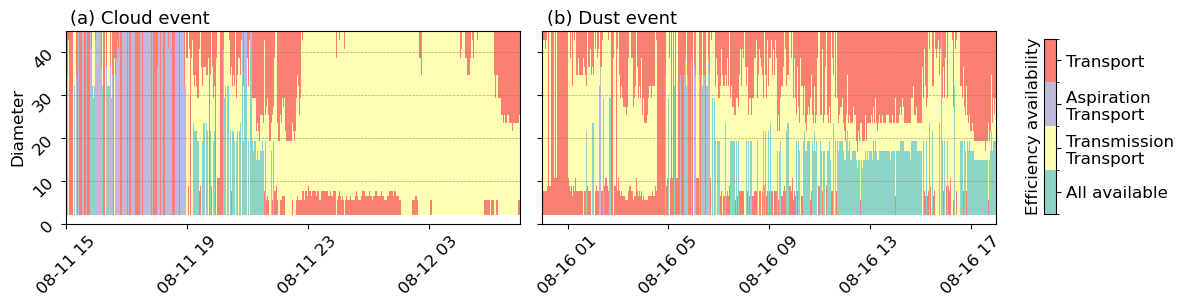

In [ ]:
import matplotlib.colors as colors
import loss_Calc_functions_GFAS101 as lc
importlib.reload(lc)

# add flags for loss calculations
fl = eff_cloud
p = fl.index.values
y = fl.columns.astype(float) *10**6
P,Y = np.meshgrid(p,y)
E = fl.astype(float).values.T

fl2 = eff_dust
a = fl2.index.values
b = fl2.columns.astype(float) *10**6
A,B = np.meshgrid(a,b)
C = fl2.astype(float).values.T

norm_c = colors.BoundaryNorm(boundaries= np.linspace(-0.5, int(fl.values.max()) + 0.5, int(fl.values.max()) + 2), ncolors= int(fl.values.max())+1)
norm_d = colors.BoundaryNorm(boundaries= np.linspace(-0.5, int(fl2.values.max()) + 0.5, int(fl2.values.max()) + 2), ncolors= int(fl2.values.max())+1)


fig, ax = plt.subplots(1, 2, figsize=(12,2.5), sharey = True)
c = ax[0].pcolor(P,Y,E, cmap='Set3', norm = norm_c) #vmin=10**(-2),vmax=10**3
d = ax[1].pcolor(A,B,C, cmap='Set3', norm = norm_d)
ax[0].set(ylim = (0,45), ylabel = 'Diameter')

dax = fig.add_axes([0.94,0.15,0.01,0.7]) # [(position:) left, bottom, (size:) width, height]
dbar = fig.colorbar(c, orientation='vertical', cax = dax, label ='Efficiency availability' )

for axs in ax:       
    axs.tick_params(axis='both',which='major', rotation = 45)
    axs.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    myFmt = mdates.DateFormatter('%m-%d %H')
    axs.xaxis.set_major_formatter(myFmt)
    axs.grid(which = 'major', axis = 'y', color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
lc.plot_flag_parameters(fl.values, dbar)

dbar.set_label('Efficiency availability', labelpad=-110,  fontsize = 12)#y=1.15, rotation=270,

ax[0].text(0.01,1.11, '(a) Cloud event', transform=ax[0].transAxes, fontsize=13, va='top', ha='left', 
               )
ax[1].text(0.01,1.11, '(b) Dust event', transform=ax[1].transAxes, fontsize=13, va='top', ha='left', 
               )

plt.subplots_adjust(wspace = 0.05)
if save_plots ==True:
    fig.savefig(f'{save_plots_path}efficiency_available_{day}.png', bbox_inches='tight', dpi = 300)
